# ==========================================================
# STUDENT MARKS PREDICTION USING LINEAR REGRESSION
# ==========================================================

In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
# Import required libraries
import pandas as pd

# ==========================================================
# LOAD DATASET
# ==========================================================

# Read CSV file from Google Drive
file_path = "/content/drive/MyDrive/Colab Notebooks/Models Data/Student_Marks.csv"
df = pd.read_csv(file_path)

In [26]:
# Display first few rows
df.head()

,number_courses,time_study,Marks
0,3,4.508,19.202
1,4,0.096,7.734
2,4,3.133,13.811
3,6,7.909,53.018
4,8,7.811,55.299


In [27]:
# ==========================================================
# UNDERSTAND THE DATASET
# ==========================================================

# Check number of rows and columns
print("Shape:")
print(df.shape)

# Check data types and basic information
print("\nInfo:")
print(df.info())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Generate statistical summary
print("\nStatistics:")
print(df.describe())

Shape:
(100, 3)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   number_courses  100 non-null    int64  
 1   time_study      100 non-null    float64
 2   Marks           100 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 2.5 KB
None

Missing Values:
number_courses    0
time_study        0
Marks             0
dtype: int64

Statistics:
       number_courses  time_study       Marks
count      100.000000  100.000000  100.000000
mean         5.290000    4.077140   24.417690
std          1.799523    2.372914   14.326199
min          3.000000    0.096000    5.609000
25%          4.000000    2.058500   12.633000
50%          5.000000    4.022000   20.059500
75%          7.000000    6.179250   36.676250
max          8.000000    7.957000   55.299000


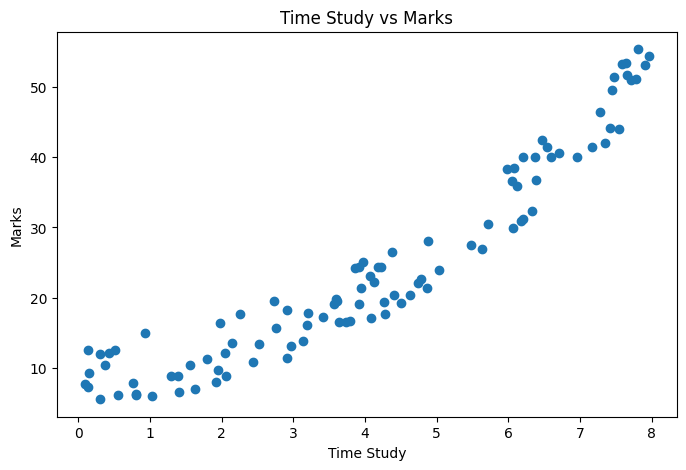

In [28]:
# ==========================================================
# VISUALIZE RELATIONSHIPS
# ==========================================================
import matplotlib.pyplot as plt

# Relationship between Study Time and Marks
plt.figure(figsize=(8,5))
plt.scatter(df["time_study"], df["Marks"])

plt.xlabel("Time Study")
plt.ylabel("Marks")
plt.title("Time Study vs Marks")

plt.show()

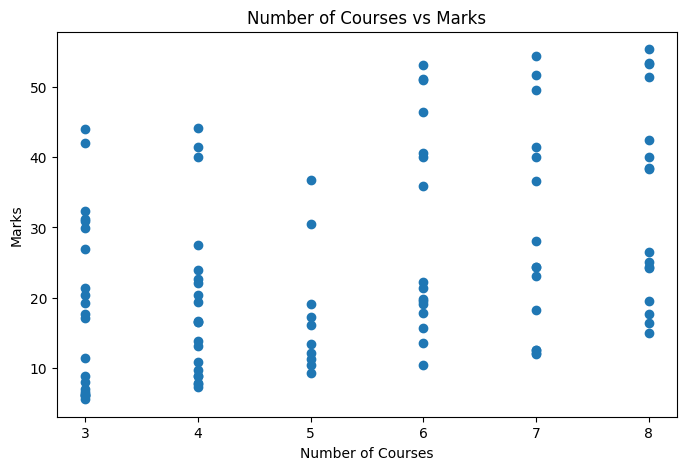

In [29]:
# Relationship between Number of Courses and Marks
plt.figure(figsize=(8,5))
plt.scatter(df["number_courses"], df["Marks"])

plt.xlabel("Number of Courses")
plt.ylabel("Marks")
plt.title("Number of Courses vs Marks")

plt.show()

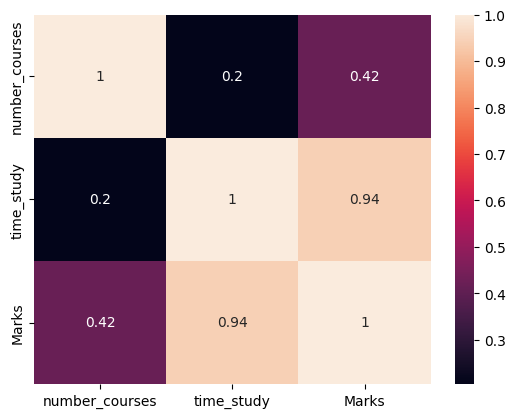

In [30]:
# ==========================================================
# CORRELATION ANALYSIS
# ==========================================================
import seaborn as sns
import matplotlib.pyplot as plt

# Check how strongly features are related
sns.heatmap(df.corr(),annot=True)
plt.show()

In [31]:
# ==========================================================
# FEATURE SELECTION
# ==========================================================

# X = Input Features
# These columns will be used to predict marks
X = df[["number_courses","time_study"]]
# Display feature data
print(X.head())

   number_courses  time_study
0               3       4.508
1               4       0.096
2               4       3.133
3               6       7.909
4               8       7.811


In [32]:
# y = Target Variable
# This is what the model will predict
y = df["Marks"]
# Display target data
print(y.head())

0    19.202
1     7.734
2    13.811
3    53.018
4    55.299
Name: Marks, dtype: float64


In [33]:
# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

# Split data into training and testing sets
# 70% for learning
# 30% for evaluation
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42)

# Verify split sizes
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(70, 2)
(30, 2)
(70,)
(30,)


In [34]:
# ==========================================================
# LINEAR REGRESSION MODEL
# ==========================================================
from sklearn.linear_model import LinearRegression

# Create Linear Regression model
lr_model = LinearRegression()
# Train model using training data
lr_model.fit(X_train, y_train)

# ==========================================================
# MODEL EQUATION
# ==========================================================

# Intercept = Constant value (c)
print("Intercept:", lr_model.intercept_)
# Coefficients = Importance of each feature
print("Coefficients:", lr_model.coef_)

Intercept: -7.22977810143507
Coefficients: [1.90391457 5.29013558]


In [35]:
# ==========================================================
# MAKE PREDICTIONS
# ==========================================================

# Predict marks for unseen students
y_pred = lr_model.predict(X_test)
print(y_pred)

[19.2023582  38.09765401 20.14982671  9.38493504 10.72280511 45.32451345
 13.13986283 48.1912327  37.38033252 22.3298968  44.98594477 28.44262235
  7.09959647 39.07686333 28.22097089 49.32278747 36.03556961 39.66299991
 28.41141577  8.65489633 21.50778884 11.82790921  8.78501278 23.19058619
 25.07916459 22.92185775  1.12649917  0.07429642 31.13797254 22.99116375]


In [36]:
# Compare Actual vs Predicted
comparison = pd.DataFrame({"Actual": y_test,"Predicted": y_pred})

print(comparison.head(10))

    Actual  Predicted
83  16.106  19.202358
53  36.653  38.097654
70  16.606  20.149827
45   8.924   9.384935
44   9.742  10.722805
39  51.142  45.324513
22  12.209  13.139863
80  54.321  48.191233
10  42.036  37.380333
0   19.202  22.329897


In [37]:
# ==========================================================
# MODEL EVALUATION
# ==========================================================
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)

# Average prediction error
mae = mean_absolute_error(y_test,y_pred)
# Squared prediction error
mse = mean_squared_error(y_test,y_pred)
# Goodness of fit score
r2 = r2_score(y_test,y_pred)

print("Intercept:", lr_model.intercept_)
print("Coefficients:", lr_model.coef_)
print("MAE :", mae)
print("MSE :", mse)
print("R2 :", r2)

Intercept: -7.22977810143507
Coefficients: [1.90391457 5.29013558]
MAE : 3.0284743686391673
MSE : 13.104475429070757
R2 : 0.9417542675032117


In [38]:
# ==========================================================
# PREDICT FOR NEW STUDENT
# ==========================================================

# Example student data
new_student = pd.DataFrame({"number_courses": [5],"time_study": [8.2]})
# Predict marks
predicted_marks = lr_model.predict(new_student)
# Print the predicted marks
print(predicted_marks)

[45.6689065]
